# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/toBESkiii/FlyRank_AI_Intership/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

## 1. Ranked actions + reason codes

The validated Random Forest score is used to prioritise which pages should be investigated first. The score is not treated as an instruction to automatically change a page.

Each ranked page is therefore paired with a transparent reason code and a suggested human-review action based on observable page characteristics.

The playbook uses four main review archetypes:

* **STALE_VISIBLE** → `REVIEW_FOR_REFRESH`
  The page still has meaningful search visibility but has not been updated recently. A reviewer should check whether the content, examples, statistics, links or search intent have become outdated.

* **HIGH_VISIBILITY_LOW_CTR** → `REVIEW_TITLE_AND_SNIPPET`
  The page receives substantial search visibility but has relatively weak click-through behaviour. A reviewer should inspect the title, search snippet, intent alignment and query relevance before changing the content itself.

* **STRIKING_DISTANCE** → `REVIEW_CONTENT_EXPANSION`
  The page has meaningful visibility and an average search position around 11–20. A reviewer should inspect whether the page could benefit from stronger coverage, clearer intent alignment or supporting internal links.

* **HIGH_MODEL_SCORE** → `MANUAL_DIAGNOSTIC_REVIEW`
  The model ranks the page highly but it does not match one of the clearer archetypes above. A human should investigate the page and its search context before deciding whether any action is justified.

These actions are **decision-support recommendations**, not automated interventions. The Random Forest score indicates which pages look worth reviewing first within the measured data; it does not establish that a particular action will improve search performance.


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier


# ---------------------------------------------------------
# 1. Load the same data used by the validated model
# ---------------------------------------------------------

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "toBESkiii/FlyRank_AI_Intership/main/"
    "data/raw/content_refresh_anonymized.csv"
)

page_dataset = pd.read_csv(DATA_URL)

# Same observed proxy used in Weeks 5 and 6
page_dataset["decline_proxy"] = (
    page_dataset["trend_direction"] == "down"
).astype(int)

print("Dataset loaded:", page_dataset.shape)


# ---------------------------------------------------------
# 2. Reproduce the same validated feature set
# ---------------------------------------------------------

model_features = [
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "avg_position",
    "search_volume"
]

model_data = page_dataset.copy()

# Position 0 means unavailable, not genuine rank 0
model_data["avg_position"] = (
    model_data["avg_position"]
    .replace(0, np.nan)
)

X = model_data[model_features].copy()
y = model_data["decline_proxy"].copy()


# ---------------------------------------------------------
# 3. Reproduce the grouped client split
# ---------------------------------------------------------

grouped_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_indices, test_indices = next(
    grouped_split.split(
        X,
        y=y,
        groups=model_data["client_id"]
    )
)

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()


# ---------------------------------------------------------
# 4. Reproduce the validated Random Forest
# ---------------------------------------------------------

random_forest_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                min_samples_leaf=10,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_scores = (
    random_forest_model
    .predict_proba(X_test)[:, 1]
)


# ---------------------------------------------------------
# 5. Create the ranked playbook queue
# ---------------------------------------------------------

action_queue = (
    model_data
    .iloc[test_indices]
    [
        [
            "content_id",
            "client_id",
            "days_since_last_update",
            "impressions_90d",
            "ctr",
            "avg_position",
            "search_volume",
            "decline_proxy"
        ]
    ]
    .copy()
)

# The validated model probability becomes the priority score
action_queue["priority_score"] = random_forest_scores


# ---------------------------------------------------------
# 6. Define transparent action thresholds
# ---------------------------------------------------------

minimum_visibility = 300

# Learn the low-CTR threshold from TRAINING data only
low_ctr_threshold = X_train["ctr"].median()

print(
    "Low CTR threshold from training data:",
    round(low_ctr_threshold, 3)
)


# ---------------------------------------------------------
# 7. Assign one primary reason code + action
# ---------------------------------------------------------

def assign_action(page):

    # Strong visibility but relatively weak CTR
    if (
        page["impressions_90d"] >= minimum_visibility
        and page["ctr"] < low_ctr_threshold
    ):
        return pd.Series(
            [
                "HIGH_VISIBILITY_LOW_CTR",
                "REVIEW_TITLE_AND_SNIPPET"
            ]
        )

    # Page ranking just outside page-one territory
    if (
        page["impressions_90d"] >= minimum_visibility
        and pd.notna(page["avg_position"])
        and 10 < page["avg_position"] <= 20
    ):
        return pd.Series(
            [
                "STRIKING_DISTANCE",
                "REVIEW_CONTENT_EXPANSION"
            ]
        )

    # Older page that still has meaningful visibility
    if (
        page["days_since_last_update"] >= 90
        and page["impressions_90d"] >= minimum_visibility
    ):
        return pd.Series(
            [
                "STALE_VISIBLE",
                "REVIEW_FOR_REFRESH"
            ]
        )

    # Model ranks it highly, but simple rules do not explain it
    return pd.Series(
        [
            "HIGH_MODEL_SCORE",
            "MANUAL_DIAGNOSTIC_REVIEW"
        ]
    )


action_queue[
    ["reason_code", "action_label"]
] = action_queue.apply(
    assign_action,
    axis=1
)


# ---------------------------------------------------------
# 8. Rank pages from highest to lowest priority
# ---------------------------------------------------------

action_queue = (
    action_queue
    .sort_values(
        by="priority_score",
        ascending=False
    )
    .reset_index(drop=True)
)

action_queue.insert(
    0,
    "review_rank",
    range(1, len(action_queue) + 1)
)


# ---------------------------------------------------------
# 9. Inspect the resulting playbook
# ---------------------------------------------------------

print("\nPages in action queue:", len(action_queue))

print("\nAction counts:")
display(
    action_queue["action_label"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="pages")
)

print("\nTop 20 ranked actions:")

display(
    action_queue[
        [
            "review_rank",
            "content_id",
            "priority_score",
            "reason_code",
            "action_label",
            "days_since_last_update",
            "impressions_90d",
            "ctr",
            "avg_position"
        ]
    ].head(20)
)

Dataset loaded: (30000, 45)
Low CTR threshold from training data: 0.08

Pages in action queue: 6163

Action counts:


,action,pages
0,MANUAL_DIAGNOSTIC_REVIEW,4176
1,REVIEW_TITLE_AND_SNIPPET,977
2,REVIEW_CONTENT_EXPANSION,668
3,REVIEW_FOR_REFRESH,342



Top 20 ranked actions:


,review_rank,content_id,priority_score,reason_code,action_label,days_since_last_update,impressions_90d,ctr,avg_position
0,1,content_26d48a980581,0.799401,HIGH_VISIBILITY_LOW_CTR,REVIEW_TITLE_AND_SNIPPET,106,1266,0.00,4.6
1,2,content_829c68e60d13,0.791887,HIGH_VISIBILITY_LOW_CTR,REVIEW_TITLE_AND_SNIPPET,106,307,0.00,4.9
2,3,content_f55fd2d8ed04,0.789607,STALE_VISIBLE,REVIEW_FOR_REFRESH,104,2237,0.09,1.3
3,4,content_64a482194d7a,0.786798,HIGH_VISIBILITY_LOW_CTR,REVIEW_TITLE_AND_SNIPPET,20,20971,0.06,35.8
4,5,content_50cd61b8e18d,0.785401,HIGH_VISIBILITY_LOW_CTR,REVIEW_TITLE_AND_SNIPPET,14,3799,0.05,19.1
5,6,content_e3ce3f8b5844,0.778650,STALE_VISIBLE,REVIEW_FOR_REFRESH,104,858,0.12,2.2
6,7,content_a138ab3bd14d,0.777664,HIGH_MODEL_SCORE,MANUAL_DIAGNOSTIC_REVIEW,104,200,0.00,1.9
7,8,content_c65ee459f729,0.776407,HIGH_VISIBILITY_LOW_CTR,REVIEW_TITLE_AND_SNIPPET,106,6526,0.00,17.4
8,9,content_b4c79208b569,0.775304,HIGH_VISIBILITY_LOW_CTR,REVIEW_TITLE_AND_SNIPPET,104,3245,0.06,1.9
9,10,content_9db40e41d57d,0.774637,HIGH_VISIBILITY_LOW_CTR,REVIEW_TITLE_AND_SNIPPET,20,2083,0.05,16.3


## 2. Intended use and limits


### Intended use

This playbook is intended to support an SEO specialist or content editor who needs to decide which pages are worth investigating first.

The Random Forest priority score determines the order of review, while the reason code provides a transparent starting point for the human investigation.

The intended workflow is:

1. Review the highest-ranked pages first.
2. Use the reason code to identify what should be investigated.
3. Check the page, search context and business importance.
4. Decide whether a refresh, title/snippet review, content expansion or no action is appropriate.
5. Record the decision and outcome for future evaluation.

The model is therefore a **prioritisation and decision-support tool**, not an automated content-editing system.

### Decay and refresh insight

Earlier signal analysis showed that staleness had a mixed relationship with the observed decline proxy. In the validated Random Forest, `days_since_last_update` also had relatively weak and unstable permutation importance compared with `impressions_90d` and `avg_position`.

This suggests that content age can be a useful review signal, but age alone should not determine whether a page needs refreshing.

A stale page with meaningful visibility may deserve investigation, but the reviewer should first determine whether the information is actually outdated, whether search intent has changed and whether the page remains accurate and useful.

The playbook therefore treats freshness as a **directional review cue rather than proof that refreshing a page will improve its performance**.

### Cost and value thinking

The main value of the ranked queue is reducing the amount of content a specialist must inspect manually.

Reviewing every page has a human-time cost, so higher-ranked pages should generally receive attention before lower-ranked pages.

However, false positives also have a cost. An unnecessary refresh can consume editorial time and may alter a page that is already performing adequately.

The appropriate goal is therefore not to maximise the number of automated actions, but to place potentially valuable review opportunities near the top of the queue while retaining human judgement before changes are made.

### Known limits

This playbook has several important limitations:

* The model was developed on the 30,000-page starter dataset rather than a full production deployment.
* The target is an observed decline proxy rather than a clean future outcome.
* Recent search-performance features may overlap with the period used to define the decline proxy.
* Performance was measured using a grouped client holdout and should not be treated as guaranteed performance for every future client.
* The reason codes are transparent review heuristics rather than causal explanations of why a page declined.
* The model does not know the full business value, strategic importance, editorial quality or real search intent of each page.
* A recommended refresh does not establish that refreshing the page will improve traffic, ranking or conversions.

For these reasons, the playbook should remain a practical, non-production decision-support workflow with human review at the centre.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list


### Human review rules

Every recommendation produced by the playbook should be reviewed by a human before any content change is made.

For each high-priority page, the reviewer should check:

1. **Content accuracy** — Is the information actually outdated or incorrect?
2. **Search intent** — Does the page still match what users appear to be searching for?
3. **Business importance** — Is the page strategically valuable enough to justify editorial effort?
4. **Current performance** — Is the page already performing adequately despite the model score?
5. **Seasonality** — Could recent performance changes be explained by seasonal demand?
6. **SERP context** — Have competitors, search-result features or ranking conditions changed?
7. **Editorial risk** — Could changing the page remove useful information or damage an already successful page?

The model score should determine **review priority**, not the final editorial decision.

### What should NOT be automated

The system should not automatically:

* rewrite or publish page content;
* change page titles or meta descriptions;
* delete, redirect or prune pages;
* conclude that a page is low quality solely because of its model score;
* assume that stale content must be refreshed;
* automatically increase or reduce content length;
* make business-priority decisions without human context;
* treat a high decline-like score as proof of future decline;
* claim that a recommended intervention will improve rankings, traffic or conversions.

These decisions require context that is not fully represented in the model features.

### Human override

A reviewer should be able to override any recommendation.

For example, a page ranked highly for `STALE_VISIBLE` may still require **no action** if the information is evergreen, accurate and performing well.

Similarly, a page classified as `HIGH_VISIBILITY_LOW_CTR` may not need a title or snippet change if the low CTR is expected for the query type or search-result layout.

The final action should therefore be recorded as one of:

* `REFRESH`
* `TITLE_SNIPPET_REVIEW`
* `CONTENT_EXPANSION`
* `MONITOR`
* `NO_ACTION`
* `NEEDS_MORE_INVESTIGATION`

This creates a human-reviewed feedback trail that could later be used to evaluate whether the playbook is recommending useful actions.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

The current playbook is an experimental decision-support system rather than a production deployment. Monitoring should therefore focus on a small number of practical signals that indicate whether the ranking is becoming less useful.

### What I would monitor

I would periodically monitor:

* **Precision@10** — whether the very highest-ranked recommendations still match the observed decline proxy.
* **Precision@50** — whether the larger review queue remains useful.
* **Top-50 false-positive rate** — how many high-priority recommendations do not match the decline proxy.
* **Feature distributions** — whether important inputs such as impressions, average position and CTR begin to look substantially different from the data used to train the model.
* **Reason-code distribution** — whether one action type suddenly dominates the queue.
* **Human-review outcomes** — how often reviewers choose `NO_ACTION` or override the suggested action.

The grouped-client validation result provides the current reference point:

* Precision@10: **0.80**
* Precision@50: **0.78**

These values are measured benchmarks from the held-out client split, not guaranteed future targets.

### Retrain or investigate when

I would trigger a model review when one or more of the following occurs:

1. Precision@50 falls substantially below the validated benchmark across repeated evaluations.
2. Precision@10 or Precision@50 shows a persistent downward trend rather than a one-off fluctuation.
3. The proportion of high-ranked false positives increases noticeably.
4. Important feature distributions change substantially, suggesting that current pages no longer resemble the original training data.
5. New clients or content types behave differently from those represented in the training data.
6. Human reviewers frequently override recommendations or select `NO_ACTION`.
7. The definition of the decline proxy, available features or data collection process changes.

A retraining decision should not be triggered by one unusual page or a single weak evaluation. The change should be repeated or large enough to suggest that the model-data relationship has shifted.

### Retraining approach

If retraining is required, the model should be trained on updated historical data and evaluated again using a grouped client-level or appropriate time-aware holdout.

The retrained model should only replace the existing model if it provides a meaningful improvement on the same decision-support metrics without introducing new leakage or validation concerns.

Monitoring therefore acts as a safeguard: it helps determine when the ranking should be re-evaluated rather than assuming that the original measured performance will remain stable indefinitely.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper


This notebook exports the validated action playbook so that the recommendations section of the research paper can be built from reproducible evidence rather than manually copied results.

The exported ranked queue contains the model priority score, reason code, suggested human-review action and the observable signals needed to understand each recommendation.

The decline proxy is retained inside the notebook for evaluation but is excluded from the operational queue exported for reviewers because it should not be treated as information available to the decision-maker.

I also export a small metrics JSON containing the validation design, Precision@10, Precision@50, test base rate, model name and action counts. This provides a traceable source for numerical claims used in the paper.

Finally, I export a figure showing the distribution of suggested review actions. The CSV remains outside Git version control by design, while the metrics JSON and reusable figure can be committed as evidence supporting the final paper.


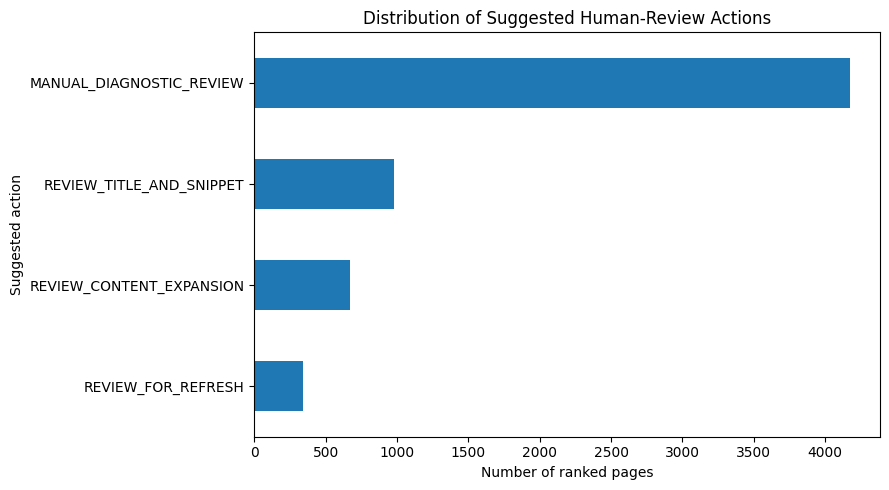

EXPORTS CREATED SUCCESSFULLY

Ranked queue:
work/outputs/action_playbook_queue.csv

Metrics receipt:
work/outputs/action_playbook_metrics.json

Paper figure:
work/figures/action_playbook_action_distribution.png

Paper metrics:
{
  "lane": "Refresh / Content Opportunity Scoring",
  "model": "Random Forest",
  "validation_design": "Grouped client holdout",
  "training_pages": 23837,
  "test_pages": 6163,
  "test_base_rate": 0.511,
  "precision_at_10": 0.8,
  "precision_at_50": 0.78,
  "low_ctr_threshold": 0.08,
  "number_of_ranked_pages": 6163,
  "action_counts": {
    "MANUAL_DIAGNOSTIC_REVIEW": 4176,
    "REVIEW_TITLE_AND_SNIPPET": 977,
    "REVIEW_CONTENT_EXPANSION": 668,
    "REVIEW_FOR_REFRESH": 342
  },
  "interpretation": "Observed decision-support performance on a grouped client holdout; not a guarantee of future decline or intervention impact."
}


In [2]:
from pathlib import Path
import json
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Create export directories
# ---------------------------------------------------------

output_directory = Path("work/outputs")
figure_directory = Path("work/figures")

output_directory.mkdir(
    parents=True,
    exist_ok=True
)

figure_directory.mkdir(
    parents=True,
    exist_ok=True
)


# ---------------------------------------------------------
# 2. Build the operational ranked queue
# ---------------------------------------------------------

export_columns = [
    "review_rank",
    "content_id",
    "client_id",
    "priority_score",
    "reason_code",
    "action_label",
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "avg_position",
    "search_volume"
]

paper_action_queue = (
    action_queue[export_columns]
    .copy()
)

queue_output_path = (
    output_directory /
    "action_playbook_queue.csv"
)

paper_action_queue.to_csv(
    queue_output_path,
    index=False
)


# ---------------------------------------------------------
# 3. Calculate validation metrics for the paper
# ---------------------------------------------------------

precision_at_10 = (
    action_queue
    .head(10)["decline_proxy"]
    .mean()
)

precision_at_50 = (
    action_queue
    .head(50)["decline_proxy"]
    .mean()
)

test_base_rate = (
    action_queue["decline_proxy"]
    .mean()
)

action_counts = (
    action_queue["action_label"]
    .value_counts()
    .to_dict()
)


# ---------------------------------------------------------
# 4. Create a metrics receipt
# ---------------------------------------------------------

paper_metrics = {
    "lane": "Refresh / Content Opportunity Scoring",
    "model": "Random Forest",
    "validation_design": "Grouped client holdout",
    "training_pages": int(len(X_train)),
    "test_pages": int(len(X_test)),
    "test_base_rate": round(
        float(test_base_rate),
        3
    ),
    "precision_at_10": round(
        float(precision_at_10),
        3
    ),
    "precision_at_50": round(
        float(precision_at_50),
        3
    ),
    "low_ctr_threshold": round(
        float(low_ctr_threshold),
        3
    ),
    "number_of_ranked_pages": int(
        len(action_queue)
    ),
    "action_counts": {
        str(action): int(count)
        for action, count in action_counts.items()
    },
    "interpretation": (
        "Observed decision-support performance "
        "on a grouped client holdout; not a "
        "guarantee of future decline or intervention impact."
    )
}

metrics_output_path = (
    output_directory /
    "action_playbook_metrics.json"
)

with open(
    metrics_output_path,
    "w",
    encoding="utf-8"
) as metrics_file:
    json.dump(
        paper_metrics,
        metrics_file,
        indent=2
    )


# ---------------------------------------------------------
# 5. Create a reusable paper figure
# ---------------------------------------------------------

action_distribution = (
    action_queue["action_label"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))

action_distribution.plot(
    kind="barh"
)

plt.title(
    "Distribution of Suggested Human-Review Actions"
)

plt.xlabel("Number of ranked pages")
plt.ylabel("Suggested action")

plt.tight_layout()

figure_output_path = (
    figure_directory /
    "action_playbook_action_distribution.png"
)

plt.savefig(
    figure_output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 6. Confirm exports
# ---------------------------------------------------------

print("EXPORTS CREATED SUCCESSFULLY")

print("\nRanked queue:")
print(queue_output_path)

print("\nMetrics receipt:")
print(metrics_output_path)

print("\nPaper figure:")
print(figure_output_path)

print("\nPaper metrics:")
print(json.dumps(paper_metrics, indent=2))

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.